# 05_04 Diagnosing bad Pseudo 890 origins

This notebook diagnoses the difficult Pseudo 890 weeks identified after aggregating the selected two-stage LightGBM forecasts in `05_03`. No model is retrained.

The weekly origins are seven days apart and the forecast horizon is seven days, so target windows do not overlap. Every target date belongs to exactly one origin: a bad origin is a bad calendar week, not forecast-age degradation within overlapping horizons.

## Diagnostic order

1. Rank weeks by absolute error kilograms before inspecting WAPE.
2. Use the article-day forecast/actual ratio to separate level from allocation error.
3. Locate the target days carrying each bad week's error and inspect their event-lift inputs.
4. Separate occurrence-probability from positive-quantity calibration.
5. Measure whether article errors are broad or concentrated.
6. Overlay public holidays, pre-holiday days, bridge days, school holidays, the first full week after Easter, and Corpus Christi as a non-public observance in Niedersachsen.
7. Check whether calendar demand patterns recur in the initial training origins and whether occurrence-stage errors recur in persisted validation predictions.
8. Compare the 13 April `rolling_24_mean` feature with a four-week pre-run-up baseline and relate the displacement to each series' forecast/actual ratio.

In [1]:
from pathlib import Path
import json
import sys

import duckdb
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'src').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models.benchmark import load_benchmark_design
from src.models.lightgbm import LIGHTGBM_MODEL_LABELS, TWO_STAGE_MODEL_NAME
from src.models.lightgbm.features.builder import _holiday_calendar

pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 100)

ANALYSIS_MODEL = TWO_STAGE_MODEL_NAME
SOURCE_GROUP = 'Pseudo'
CATEGORY_ID = 890
BAD_ORIGIN_COUNT = 3
LEVEL_RATIO_TOLERANCE = 0.10
FEATURE_BUILDER_VERSION = '2026-08-06.18'
FEATURE_FINGERPRINT = 'b07ab9e05a6fbf312d85'
FEATURE_GENERATION = (
    ROOT / 'data' / 'processed' / 'model_features'
    / 'lightgbm_daily' / 'v1' / FEATURE_FINGERPRINT
)
V18_RESULTS_DIR = ROOT / 'reports' / 'results' / 'backup_pre_position_lift'

In [2]:
design = load_benchmark_design()
forecast_path = V18_RESULTS_DIR / 'forecasts_two_stage.csv'
if not forecast_path.exists():
    raise FileNotFoundError(
        f'Missing feature-builder {FEATURE_BUILDER_VERSION} forecast: {forecast_path}'
    )
con = duckdb.connect()
con.execute('PRAGMA threads=4')
con.execute(
    '''
    CREATE OR REPLACE TEMP TABLE pseudo_890_rows AS
    SELECT
        ARTIKEL_ID::BIGINT AS ARTIKEL_ID,
        MARKT_ID::BIGINT AS MARKT_ID,
        CAST(origin AS DATE) AS origin,
        CAST(period AS DATE) AS period,
        actual::DOUBLE AS actual, forecast::DOUBLE AS forecast,
        occurrence_probability::DOUBLE AS occurrence_probability,
        positive_quantity_forecast::DOUBLE AS positive_quantity_forecast,
        is_active::BOOLEAN AS is_active
    FROM read_csv_auto(?)
    WHERE sourcing_group = ? AND category_id = ?
    ''',
    [str(forecast_path), SOURCE_GROUP, CATEGORY_ID],
)
con.execute(
    '''CREATE OR REPLACE TEMP VIEW pseudo_890_active AS
    SELECT * FROM pseudo_890_rows WHERE is_active'''
)

structure_audit = con.execute(
    '''
    WITH period_mapping AS (
        SELECT period, COUNT(DISTINCT origin) AS origins_per_target_date
        FROM pseudo_890_rows
        GROUP BY period
    ), origin_bounds AS (
        SELECT origin, MIN(period) AS first_period, MAX(period) AS last_period
        FROM pseudo_890_rows
        GROUP BY origin
    )
    SELECT
        (SELECT COUNT(DISTINCT origin) FROM pseudo_890_rows) AS origins,
        (SELECT COUNT(*) FROM period_mapping) AS target_dates,
        (SELECT MAX(origins_per_target_date) FROM period_mapping)
            AS maximum_origins_per_target_date,
        MIN(DATE_DIFF('day', first_period, last_period) + 1)
            AS minimum_horizon_days,
        MAX(DATE_DIFF('day', first_period, last_period) + 1)
            AS maximum_horizon_days
    FROM origin_bounds
    '''
).fetchdf()
origins = pd.DatetimeIndex(
    con.execute('SELECT DISTINCT origin FROM pseudo_890_rows ORDER BY origin')
    .fetchdf().origin
)
origin_gaps = origins.to_series().diff().dropna().dt.days.unique()
if not (
    structure_audit.loc[0, 'maximum_origins_per_target_date'] == 1
    and structure_audit.loc[0, 'minimum_horizon_days'] == design.forecast_horizon_days
    and structure_audit.loc[0, 'maximum_horizon_days'] == design.forecast_horizon_days
    and np.array_equal(origin_gaps, [design.origin_spacing_days])
):
    raise ValueError('Origins are not non-overlapping seven-day windows')
structure_audit['origin_spacing_days'] = int(origin_gaps[0])
print(f'Model: {LIGHTGBM_MODEL_LABELS[ANALYSIS_MODEL]}')
display(structure_audit)

Model: Two-stage LightGBM (occurrence × quantity)


,origins,target_dates,maximum_origins_per_target_date,minimum_horizon_days,maximum_horizon_days,origin_spacing_days
0,20,140,1,7,7,7


## 1–2. Real bad weeks, then level versus shape

Forecasts and actuals are first pooled across stores within each article-target-day. Origin WAPE is then computed from article-day errors. The three investigation weeks are selected by absolute error kilograms, not by WAPE. A forecast/actual ratio outside 0.90–1.10 is labelled a level miss; a high WAPE with a ratio near one is labelled an allocation/shape miss.

In [3]:
con.execute(
    '''
    CREATE OR REPLACE TEMP TABLE pseudo_890_article_day AS
    SELECT
        ARTIKEL_ID, origin, period,
        SUM(actual) AS actual, SUM(forecast) AS forecast
    FROM pseudo_890_active
    GROUP BY ARTIKEL_ID, origin, period
    '''
)
origin_results = con.execute(
    '''
    SELECT
        origin, SUM(actual) AS actual_kg, SUM(forecast) AS forecast_kg,
        SUM(ABS(forecast - actual)) AS absolute_error_kg,
        SUM(ABS(forecast - actual)) / NULLIF(SUM(actual), 0) AS pooled_wape,
        SUM(forecast) / NULLIF(SUM(actual), 0) AS ratio
    FROM pseudo_890_article_day
    GROUP BY origin
    ORDER BY origin
    '''
).fetchdf()
origin_results['absolute_error_rank'] = (
    origin_results.absolute_error_kg.rank(method='min', ascending=False).astype(int)
)
origin_results['wape_rank'] = (
    origin_results.pooled_wape.rank(method='min', ascending=False).astype(int)
)
origin_results['actual_volume_rank'] = (
    origin_results.actual_kg.rank(method='min', ascending=False).astype(int)
)
origin_results['diagnosis'] = np.where(
    origin_results.ratio.sub(1).abs().gt(LEVEL_RATIO_TOLERANCE),
    np.where(origin_results.ratio.gt(1), 'level: overforecast', 'level: underforecast'),
    'allocation/shape',
)
origin_results = origin_results.sort_values(
    'absolute_error_rank'
).reset_index(drop=True)
bad_origins = origin_results.head(BAD_ORIGIN_COUNT).copy()
bad_origin_keys = bad_origins[['origin']].copy()
con.register('bad_origin_keys', bad_origin_keys)

display(origin_results.style.format({
    'origin': '{:%Y-%m-%d}', 'actual_kg': '{:,.1f}',
    'forecast_kg': '{:,.1f}', 'absolute_error_kg': '{:,.1f}',
    'pooled_wape': '{:.2%}', 'ratio': '{:.3f}',
    'absolute_error_rank': '{:,.0f}', 'wape_rank': '{:,.0f}',
    'actual_volume_rank': '{:,.0f}',
}))
print('Selected bad origins (top absolute-error weeks)')
display(bad_origins.style.format({
    'origin': '{:%Y-%m-%d}', 'actual_kg': '{:,.1f}',
    'forecast_kg': '{:,.1f}', 'absolute_error_kg': '{:,.1f}',
    'pooled_wape': '{:.2%}', 'ratio': '{:.3f}',
}))

,origin,actual_kg,forecast_kg,absolute_error_kg,pooled_wape,ratio,absolute_error_rank,wape_rank,actual_volume_rank,diagnosis
0,2026-05-18,"186,300.3","140,975.8","68,497.3",36.77%,0.757,1,2,1,level: underforecast
1,2026-04-27,"151,230.4","117,465.9","47,315.2",31.29%,0.777,2,4,3,level: underforecast
2,2026-03-30,"178,733.8","144,044.2","46,591.3",26.07%,0.806,3,8,2,level: underforecast
3,2026-04-13,"124,003.4","163,637.6","43,879.3",35.39%,1.320,4,3,12,level: overforecast
4,2026-06-22,"106,414.7","107,078.2","41,908.2",39.38%,1.006,5,1,20,allocation/shape
5,2026-06-15,"136,854.3","138,505.5","35,974.7",26.29%,1.012,6,7,5,allocation/shape
6,2026-05-11,"116,619.2","119,646.8","33,584.5",28.80%,1.026,7,5,15,allocation/shape
7,2026-03-02,"147,760.3","141,704.7","32,219.3",21.81%,0.959,8,16,4,allocation/shape
8,2026-05-04,"131,903.2","114,949.1","31,579.2",23.94%,0.871,9,12,6,level: underforecast
9,2026-06-08,"128,378.7","142,165.1","31,000.9",24.15%,1.107,10,11,8,level: overforecast


Selected bad origins (top absolute-error weeks)


,origin,actual_kg,forecast_kg,absolute_error_kg,pooled_wape,ratio,absolute_error_rank,wape_rank,actual_volume_rank,diagnosis
0,2026-05-18,"186,300.3","140,975.8","68,497.3",36.77%,0.757,1,2,1,level: underforecast
1,2026-04-27,"151,230.4","117,465.9","47,315.2",31.29%,0.777,2,4,3,level: underforecast
2,2026-03-30,"178,733.8","144,044.2","46,591.3",26.07%,0.806,3,8,2,level: underforecast


## Calendar overlay

Public holidays and ±3-day event names reproduce the Niedersachsen calendar used by the model features. School-holiday ranges come from the [official Niedersachsen Ministry of Education schedule](https://www.mk.niedersachsen.de/startseite/service/ferientermine/schulferien-6491.html). A bridge day is a Monday before a Tuesday public holiday or a Friday after a Thursday public holiday. `week_after_easter` is the first complete Monday–Sunday week following Easter Monday. Corpus Christi is tagged as an observance on 4 June 2026 but is not treated as a statewide public holiday in Niedersachsen.

In [4]:
SCHOOL_HOLIDAY_RANGES = [
    ('Easter school holiday', '2025-04-07', '2025-04-19'),
    ('Ascension school holiday', '2025-05-30', '2025-05-30'),
    ('Pentecost school holiday', '2025-06-10', '2025-06-10'),
    ('Summer school holiday', '2025-07-03', '2025-08-13'),
    ('Autumn school holiday', '2025-10-13', '2025-10-25'),
    ('Christmas school holiday', '2025-12-22', '2026-01-05'),
    ('Half-year school holiday', '2026-02-02', '2026-02-03'),
    ('Easter school holiday', '2026-03-23', '2026-04-07'),
    ('Ascension school holiday', '2026-05-15', '2026-05-15'),
    ('Pentecost school holiday', '2026-05-26', '2026-05-26'),
    ('Summer school holiday', '2026-07-02', '2026-08-12'),
]
EASTER_MONDAYS = [pd.Timestamp('2025-04-21'), pd.Timestamp('2026-04-06')]

def make_calendar_tags(start, end):
    calendar = _holiday_calendar(start, end).copy()
    calendar['period'] = pd.to_datetime(calendar.period)
    calendar['weekday'] = calendar.period.dt.day_name()
    holiday_dates = set(calendar.loc[calendar.is_public_holiday, 'period'])
    calendar['day_before_public_holiday'] = calendar.period.add(
        pd.Timedelta(days=1)
    ).isin(holiday_dates)
    calendar['bridge_day'] = (
        (calendar.period.dt.weekday.eq(4)
         & calendar.period.sub(pd.Timedelta(days=1)).isin(holiday_dates))
        | (calendar.period.dt.weekday.eq(0)
           & calendar.period.add(pd.Timedelta(days=1)).isin(holiday_dates))
    )
    calendar['school_holiday_name'] = 'none'
    for name, first_day, last_day in SCHOOL_HOLIDAY_RANGES:
        in_range = calendar.period.between(first_day, last_day)
        calendar.loc[in_range, 'school_holiday_name'] = name
    calendar['school_holiday'] = calendar.school_holiday_name.ne('none')
    calendar['week_after_easter'] = False
    for easter_monday in EASTER_MONDAYS:
        calendar.loc[calendar.period.between(
            easter_monday + pd.Timedelta(days=7),
            easter_monday + pd.Timedelta(days=13),
        ), 'week_after_easter'] = True
    calendar['special_observance'] = np.where(
        calendar.period.eq(pd.Timestamp('2026-06-04')),
        'Corpus Christi (not NI public holiday)', 'none',
    )
    calendar['calendar_context'] = np.select(
        [
            calendar.is_public_holiday,
            calendar.day_before_public_holiday,
            calendar.bridge_day,
            calendar.week_after_easter,
            calendar.school_holiday,
            calendar.special_observance.ne('none'),
        ],
        [
            'public holiday', 'day before public holiday', 'bridge day',
            'week after Easter', 'school holiday', 'special observance',
        ],
        default='ordinary',
    )
    return calendar

training_summary = pd.read_csv(
    V18_RESULTS_DIR / 'training_summaries_two_stage.csv',
    parse_dates=[
        'evaluation_origin', 'evaluation_end', 'training_start', 'training_end',
        'validation_start', 'validation_end',
    ],
)
first_refit = training_summary.sort_values('evaluation_origin').iloc[0]
calendar_tags = make_calendar_tags(
    pd.Timestamp(first_refit.training_start),
    origins.max() + pd.Timedelta(days=design.forecast_horizon_days - 1),
)
con.register('calendar_tags', calendar_tags)
display(calendar_tags.loc[
    calendar_tags.calendar_context.ne('ordinary')
    & calendar_tags.period.between(origins.min(), origins.max() + pd.Timedelta(days=6)),
    [
        'period', 'weekday', 'calendar_context', 'event_name',
        'holiday_event_window', 'school_holiday_name', 'special_observance',
    ],
].reset_index(drop=True))

,period,weekday,calendar_context,event_name,holiday_event_window,school_holiday_name,special_observance
0,2026-03-23,Monday,school holiday,none,none,Easter school holiday,none
1,2026-03-24,Tuesday,school holiday,none,none,Easter school holiday,none
2,2026-03-25,Wednesday,school holiday,none,none,Easter school holiday,none
3,2026-03-26,Thursday,school holiday,none,none,Easter school holiday,none
4,2026-03-27,Friday,school holiday,none,none,Easter school holiday,none
5,2026-03-28,Saturday,school holiday,none,none,Easter school holiday,none
6,2026-03-29,Sunday,school holiday,none,none,Easter school holiday,none
7,2026-03-30,Monday,school holiday,none,none,Easter school holiday,none
8,2026-03-31,Tuesday,school holiday,Karfreitag,before_holiday_1_3d,Easter school holiday,none
9,2026-04-01,Wednesday,school holiday,Karfreitag,before_holiday_1_3d,Easter school holiday,none


In [5]:
manifest_path = FEATURE_GENERATION / 'manifest.json'
manifest = json.loads(manifest_path.read_text())
if (
    manifest.get('fingerprint') != FEATURE_FINGERPRINT
    or manifest.get('signature', {}).get('feature_builder_version')
        != FEATURE_BUILDER_VERSION
):
    raise ValueError(f'Unexpected feature generation: {manifest_path}')
feature_generation = FEATURE_GENERATION

## 3. Which target day carries the error?

`article_day_absolute_error_kg` retains article-level errors after pooling stores. `portfolio_level_error_kg` is the absolute error after also pooling articles and therefore isolates the daily total-level miss. Public-holiday dates with no active forecast rows remain visible as zero-volume calendar rows.

In [6]:
bad_day_metrics = con.execute(
    '''
    SELECT
        d.origin, d.period, COUNT(*) AS articles,
        SUM(d.actual) AS actual_kg, SUM(d.forecast) AS forecast_kg,
        SUM(ABS(d.forecast - d.actual)) AS article_day_absolute_error_kg,
        ABS(SUM(d.forecast) - SUM(d.actual)) AS portfolio_level_error_kg
    FROM pseudo_890_article_day AS d
    INNER JOIN bad_origin_keys AS b USING (origin)
    GROUP BY d.origin, d.period
    '''
).fetchdf()
bad_day_grid = pd.concat([
    pd.DataFrame({
        'origin': origin,
        'period': pd.date_range(origin, periods=design.forecast_horizon_days),
    })
    for origin in bad_origins.origin
], ignore_index=True)
bad_days = (
    bad_day_grid.merge(
        bad_day_metrics, on=['origin', 'period'], how='left', validate='one_to_one'
    )
    .merge(calendar_tags, on='period', how='left', validate='many_to_one')
)
metric_columns = [
    'articles', 'actual_kg', 'forecast_kg',
    'article_day_absolute_error_kg', 'portfolio_level_error_kg',
]
bad_days[metric_columns] = bad_days[metric_columns].fillna(0)
bad_days['ratio'] = bad_days.forecast_kg / bad_days.actual_kg.replace(0, np.nan)
bad_days['error_share_within_origin'] = (
    bad_days.article_day_absolute_error_kg
    / bad_days.groupby('origin').article_day_absolute_error_kg.transform('sum')
)
bad_days = bad_days.sort_values(['origin', 'period']).reset_index(drop=True)
display(bad_days[[
    'origin', 'period', 'weekday', 'calendar_context', 'event_name',
    'holiday_event_window', 'school_holiday_name', 'articles',
    'actual_kg', 'forecast_kg', 'ratio',
    'article_day_absolute_error_kg', 'portfolio_level_error_kg',
    'error_share_within_origin',
]].style.format({
    'origin': '{:%Y-%m-%d}', 'period': '{:%Y-%m-%d}',
    'articles': '{:,.0f}', 'actual_kg': '{:,.1f}',
    'forecast_kg': '{:,.1f}', 'ratio': '{:.3f}',
    'article_day_absolute_error_kg': '{:,.1f}',
    'portfolio_level_error_kg': '{:,.1f}',
    'error_share_within_origin': '{:.1%}',
}))

contributing_stores = con.execute(
    '''
    SELECT
        r.origin, r.period, COUNT(DISTINCT r.MARKT_ID) AS active_stores,
        LIST_SORT(LIST(DISTINCT r.MARKT_ID)) AS active_store_ids,
        SUM(r.actual) AS actual_kg, SUM(r.forecast) AS forecast_kg
    FROM pseudo_890_active AS r
    INNER JOIN bad_origin_keys AS b USING (origin)
    GROUP BY r.origin, r.period
    '''
).fetchdf()
stores_by_day = (
    bad_day_grid.merge(
        contributing_stores,
        on=['origin', 'period'], how='left', validate='one_to_one',
    )
    .merge(
        calendar_tags[['period', 'weekday']],
        on='period', how='left', validate='many_to_one',
    )
)
stores_by_day['active_stores'] = stores_by_day.active_stores.fillna(0).astype(int)
stores_by_day[['actual_kg', 'forecast_kg']] = stores_by_day[[
    'actual_kg', 'forecast_kg'
]].fillna(0)
stores_by_day['active_store_key'] = stores_by_day.active_store_ids.apply(
    lambda values: tuple(int(value) for value in values)
    if isinstance(values, np.ndarray) else tuple()
)

store_pool_audit = stores_by_day.merge(
    bad_days[['origin', 'period', 'actual_kg', 'forecast_kg']],
    on=['origin', 'period'], suffixes=('_stores', '_day_table'),
    validate='one_to_one',
)
if not (
    np.allclose(store_pool_audit.actual_kg_stores, store_pool_audit.actual_kg_day_table)
    and np.allclose(
        store_pool_audit.forecast_kg_stores, store_pool_audit.forecast_kg_day_table
    )
):
    raise ValueError('Store-level pools do not reproduce the Section 3 totals')
sunday_stores = stores_by_day.loc[stores_by_day.weekday.eq('Sunday')]
if not sunday_stores.active_stores.eq(0).all():
    raise ValueError('Every Sunday must contain zero active stores')

unique_store_keys = list(dict.fromkeys(stores_by_day.active_store_key))
store_set_labels = {key: f'S{position}' for position, key in enumerate(unique_store_keys)}
stores_by_day['store_set'] = stores_by_day.active_store_key.apply(
    lambda key: store_set_labels[key]
)
store_set_details = pd.DataFrame([
    {
        'store_set': store_set_labels[key],
        'n_active_stores': len(key),
        'active_store_ids': ', '.join(str(value) for value in key) or 'none',
    }
    for key in unique_store_keys
])

print('Active stores contributing to each pooled day')
display(stores_by_day[[
    'origin', 'period', 'weekday', 'active_stores', 'store_set',
    'actual_kg', 'forecast_kg',
]].style.format({
    'origin': '{:%Y-%m-%d}', 'period': '{:%Y-%m-%d}',
    'active_stores': '{:,.0f}', 'actual_kg': '{:,.1f}',
    'forecast_kg': '{:,.1f}',
}))
print('Store-set definitions (IDs listed once per unique set)')
display(store_set_details)

,origin,period,weekday,calendar_context,event_name,holiday_event_window,school_holiday_name,articles,actual_kg,forecast_kg,ratio,article_day_absolute_error_kg,portfolio_level_error_kg,error_share_within_origin
0,2026-03-30,2026-03-30,Monday,school holiday,none,none,Easter school holiday,277,"26,235.3","20,822.6",0.794,"6,763.9","5,412.8",14.5%
1,2026-03-30,2026-03-31,Tuesday,school holiday,Karfreitag,before_holiday_1_3d,Easter school holiday,277,"27,252.4","21,684.7",0.796,"6,647.4","5,567.6",14.3%
2,2026-03-30,2026-04-01,Wednesday,school holiday,Karfreitag,before_holiday_1_3d,Easter school holiday,277,"32,537.9","27,772.9",0.854,"7,510.7","4,765.0",16.1%
3,2026-03-30,2026-04-02,Thursday,day before public holiday,Karfreitag,before_holiday_1_3d,Easter school holiday,277,"42,413.6","34,906.1",0.823,"9,335.2","7,507.5",20.0%
4,2026-03-30,2026-04-03,Friday,public holiday,Karfreitag,holiday,Easter school holiday,0,0.0,0.0,nan,0.0,0.0,0.0%
5,2026-03-30,2026-04-04,Saturday,school holiday,Karfreitag,after_holiday_1_3d,Easter school holiday,277,"50,294.6","38,857.9",0.773,"16,334.1","11,436.7",35.1%
6,2026-03-30,2026-04-05,Sunday,day before public holiday,Ostermontag,before_holiday_1_3d,Easter school holiday,0,0.0,0.0,nan,0.0,0.0,0.0%
7,2026-04-27,2026-04-27,Monday,ordinary,none,none,none,278,"14,144.2","13,145.5",0.929,"2,422.8",998.7,5.1%
8,2026-04-27,2026-04-28,Tuesday,ordinary,Erster Mai,before_holiday_1_3d,none,278,"15,274.5","16,084.0",1.053,"3,015.4",809.5,6.4%
9,2026-04-27,2026-04-29,Wednesday,ordinary,Erster Mai,before_holiday_1_3d,none,278,"26,514.6","25,354.4",0.956,"4,985.0","1,160.2",10.5%


Active stores contributing to each pooled day


,origin,period,weekday,active_stores,store_set,actual_kg,forecast_kg
0,2026-05-18,2026-05-18,Monday,191,S0,"20,217.3","18,437.3"
1,2026-05-18,2026-05-19,Tuesday,191,S0,"18,245.4","17,466.8"
2,2026-05-18,2026-05-20,Wednesday,191,S0,"20,460.7","17,976.2"
3,2026-05-18,2026-05-21,Thursday,191,S0,"26,536.1","21,098.8"
4,2026-05-18,2026-05-22,Friday,191,S0,"45,758.2","30,004.2"
5,2026-05-18,2026-05-23,Saturday,191,S0,"55,082.7","35,992.4"
6,2026-05-18,2026-05-24,Sunday,0,S1,0.0,0.0
7,2026-04-27,2026-04-27,Monday,191,S0,"14,144.2","13,145.5"
8,2026-04-27,2026-04-28,Tuesday,191,S0,"15,274.5","16,084.0"
9,2026-04-27,2026-04-29,Wednesday,191,S0,"26,514.6","25,354.4"


Store-set definitions (IDs listed once per unique set)


,store_set,n_active_stores,active_store_ids
0,S0,191,"1100001, 1100002, 1100003, 1100004, 1100005, 1..."
1,S1,0,none


### Event-lift features on the selected days

`event_lift_series` varies by article-store, so the table reports its availability, mean, and median across active Pseudo 890 rows on each day. The three pooled lift features are constant across article-store rows for a given origin and event; their exact daily values are shown. Missing values are expected outside the model's ±3-day event windows or when the historical support rules are not met.

In [7]:
bad_feature_paths = [
    feature_generation / f'origin={origin.date().isoformat()}' / 'features.parquet'
    for origin in pd.to_datetime(bad_origins.origin)
]
missing_bad_feature_paths = [path for path in bad_feature_paths if not path.exists()]
if missing_bad_feature_paths:
    raise FileNotFoundError(
        f'Missing bad-origin feature partitions: {missing_bad_feature_paths}'
    )

bad_lift_features = con.execute(
    '''
    SELECT
        CAST(origin AS DATE) AS origin, CAST(period AS DATE) AS period,
        COUNT(*) FILTER (WHERE is_active) AS active_feature_rows,
        COUNT(event_lift_series) FILTER (WHERE is_active)
            AS event_lift_series_non_null_rows,
        AVG(event_lift_series) FILTER (WHERE is_active)
            AS event_lift_series_mean,
        MEDIAN(event_lift_series) FILTER (WHERE is_active)
            AS event_lift_series_median,
        ANY_VALUE(event_lift_pooled_occurrence)
            AS event_lift_pooled_occurrence,
        ANY_VALUE(event_lift_pooled_quantity)
            AS event_lift_pooled_quantity,
        ANY_VALUE(event_lift_pooled_total) AS event_lift_pooled_total,
        COUNT(DISTINCT event_lift_pooled_occurrence)
            AS pooled_occurrence_values,
        COUNT(DISTINCT event_lift_pooled_quantity) AS pooled_quantity_values,
        COUNT(DISTINCT event_lift_pooled_total) AS pooled_total_values
    FROM read_parquet(?, hive_partitioning=false)
    WHERE sourcing_group = ? AND category_id = ?
    GROUP BY origin, period
    ''',
    [[str(path) for path in bad_feature_paths], SOURCE_GROUP, CATEGORY_ID],
).fetchdf()
pooled_value_counts = bad_lift_features[[
    'pooled_occurrence_values', 'pooled_quantity_values', 'pooled_total_values',
]]
if pooled_value_counts.gt(1).any().any():
    raise ValueError('Pooled event lift is not constant within an origin-day')
bad_lift_features['event_lift_series_coverage'] = (
    bad_lift_features.event_lift_series_non_null_rows
    / bad_lift_features.active_feature_rows.replace(0, np.nan)
)
bad_lift_days = (
    bad_day_grid.merge(
        bad_lift_features.drop(columns=pooled_value_counts.columns),
        on=['origin', 'period'], how='left', validate='one_to_one',
    )
    .merge(
        calendar_tags[[
            'period', 'weekday', 'event_name', 'holiday_event_window',
        ]],
        on='period', how='left', validate='many_to_one',
    )
    .sort_values(['origin', 'period'])
    .reset_index(drop=True)
)
display(bad_lift_days[[
    'origin', 'period', 'weekday', 'event_name', 'holiday_event_window',
    'active_feature_rows', 'event_lift_series_non_null_rows',
    'event_lift_series_coverage', 'event_lift_series_mean',
    'event_lift_series_median', 'event_lift_pooled_occurrence',
    'event_lift_pooled_quantity', 'event_lift_pooled_total',
]].style.format({
    'origin': '{:%Y-%m-%d}', 'period': '{:%Y-%m-%d}',
    'active_feature_rows': '{:,.0f}',
    'event_lift_series_non_null_rows': '{:,.0f}',
    'event_lift_series_coverage': '{:.1%}',
    'event_lift_series_mean': '{:.3f}',
    'event_lift_series_median': '{:.3f}',
    'event_lift_pooled_occurrence': '{:.3f}',
    'event_lift_pooled_quantity': '{:.3f}',
    'event_lift_pooled_total': '{:.3f}',
}, na_rep='—'))

,origin,period,weekday,event_name,holiday_event_window,active_feature_rows,event_lift_series_non_null_rows,event_lift_series_coverage,event_lift_series_mean,event_lift_series_median,event_lift_pooled_occurrence,event_lift_pooled_quantity,event_lift_pooled_total
0,2026-03-30,2026-03-30,Monday,none,none,"18,553",0,0.0%,—,—,—,—,—
1,2026-03-30,2026-03-31,Tuesday,Karfreitag,before_holiday_1_3d,"18,553","15,269",82.3%,1.320,0.000,1.238,1.492,1.847
2,2026-03-30,2026-04-01,Wednesday,Karfreitag,before_holiday_1_3d,"18,553","15,329",82.6%,1.877,0.000,1.238,1.492,1.847
3,2026-03-30,2026-04-02,Thursday,Karfreitag,before_holiday_1_3d,"18,553","15,398",83.0%,2.364,0.349,1.238,1.492,1.847
4,2026-03-30,2026-04-03,Friday,Karfreitag,holiday,0,0,—,—,—,1.238,1.492,1.847
5,2026-03-30,2026-04-04,Saturday,Karfreitag,after_holiday_1_3d,"18,553","15,475",83.4%,2.884,0.645,1.238,1.492,1.847
6,2026-03-30,2026-04-05,Sunday,Ostermontag,before_holiday_1_3d,0,0,—,—,—,1.003,0.984,0.986
7,2026-04-27,2026-04-27,Monday,none,none,"18,565",0,0.0%,—,—,—,—,—
8,2026-04-27,2026-04-28,Tuesday,Erster Mai,before_holiday_1_3d,"18,565","15,263",82.2%,1.370,0.000,1.170,1.437,1.681
9,2026-04-27,2026-04-29,Wednesday,Erster Mai,before_holiday_1_3d,"18,565","15,399",82.9%,2.003,0.000,1.170,1.437,1.681


## 4. Which two-stage component missed?

Occurrence calibration compares the observed positive-row rate with mean predicted probability across all active rows. Positive-quantity calibration compares actual quantity with the predicted conditional quantity only on rows where demand was positive, matching the quantity-stage target used in `05_01`.

In [8]:
stage_by_origin = con.execute(
    '''
    SELECT
        origin, COUNT(*) AS active_rows,
        AVG((actual > 0)::INTEGER) AS actual_occurrence_rate,
        AVG(occurrence_probability) AS predicted_occurrence_rate,
        AVG(actual) FILTER (WHERE actual > 0) AS actual_positive_mean,
        AVG(positive_quantity_forecast) FILTER (WHERE actual > 0)
            AS predicted_positive_mean,
        AVG(actual) AS actual_mean_per_row, AVG(forecast) AS forecast_mean_per_row
    FROM pseudo_890_active
    GROUP BY origin
    ORDER BY origin
    '''
).fetchdf()
stage_by_origin['occurrence_gap_pp'] = 100 * (
    stage_by_origin.predicted_occurrence_rate
    - stage_by_origin.actual_occurrence_rate
)
stage_by_origin['positive_mean_ratio'] = (
    stage_by_origin.predicted_positive_mean / stage_by_origin.actual_positive_mean
)
bad_stage = stage_by_origin.merge(
    bad_origin_keys, on='origin', how='inner', validate='one_to_one'
).sort_values('origin')
display(bad_stage.style.format({
    'origin': '{:%Y-%m-%d}', 'active_rows': '{:,.0f}',
    'actual_occurrence_rate': '{:.2%}',
    'predicted_occurrence_rate': '{:.2%}',
    'occurrence_gap_pp': '{:+.2f}',
    'actual_positive_mean': '{:.3f}', 'predicted_positive_mean': '{:.3f}',
    'positive_mean_ratio': '{:.3f}',
    'actual_mean_per_row': '{:.3f}', 'forecast_mean_per_row': '{:.3f}',
}))

,origin,active_rows,actual_occurrence_rate,predicted_occurrence_rate,actual_positive_mean,predicted_positive_mean,actual_mean_per_row,forecast_mean_per_row,occurrence_gap_pp,positive_mean_ratio
0,2026-03-30,"92,765",43.25%,40.89%,4.455,3.695,1.927,1.553,-2.36,0.829
1,2026-04-27,"92,825",42.24%,39.62%,3.857,3.100,1.629,1.265,-2.62,0.804
2,2026-05-18,"111,426",41.15%,40.46%,4.063,3.082,1.672,1.265,-0.69,0.759


## 5. Broad or article-concentrated?

Article contributions sum absolute article-day errors across the seven-day origin. The top-10 share distinguishes a small product event from a broadly distributed calendar or level miss.

In [9]:
article_contributions = con.execute(
    '''
    WITH article_errors AS (
        SELECT
            d.origin, d.ARTIKEL_ID, SUM(d.actual) AS actual_kg,
            SUM(d.forecast) AS forecast_kg,
            SUM(ABS(d.forecast - d.actual)) AS absolute_error_kg
        FROM pseudo_890_article_day AS d
        INNER JOIN bad_origin_keys AS b USING (origin)
        GROUP BY d.origin, d.ARTIKEL_ID
    )
    SELECT
        *, ROW_NUMBER() OVER (
            PARTITION BY origin ORDER BY absolute_error_kg DESC
        ) AS error_rank,
        absolute_error_kg / SUM(absolute_error_kg) OVER (PARTITION BY origin)
            AS error_share
    FROM article_errors
    ORDER BY origin, error_rank
    '''
).fetchdf()
concentration_summary = (
    article_contributions.groupby('origin')
    .agg(
        articles=('ARTIKEL_ID', 'nunique'),
        top_1_error_share=('error_share', 'first'),
        top_10_error_share=(
            'error_share', lambda values: values.iloc[:10].sum()
        ),
    )
    .reset_index()
)
display(concentration_summary.style.format({
    'origin': '{:%Y-%m-%d}', 'articles': '{:,.0f}',
    'top_1_error_share': '{:.1%}', 'top_10_error_share': '{:.1%}',
}))
display(article_contributions.loc[
    article_contributions.error_rank.le(10)
].style.format({
    'origin': '{:%Y-%m-%d}', 'ARTIKEL_ID': '{:,.0f}',
    'actual_kg': '{:,.1f}', 'forecast_kg': '{:,.1f}',
    'absolute_error_kg': '{:,.1f}', 'error_rank': '{:,.0f}',
    'error_share': '{:.1%}',
}))

,origin,articles,top_1_error_share,top_10_error_share
0,2026-03-30,277,8.6%,54.1%
1,2026-04-27,278,11.9%,58.5%
2,2026-05-18,278,15.0%,57.2%


,origin,ARTIKEL_ID,actual_kg,forecast_kg,absolute_error_kg,error_rank,error_share
0,2026-03-30,"317,123","8,747.9","4,749.2","3,998.7",1,8.6%
1,2026-03-30,"316,835","11,744.8","7,846.0","3,898.8",2,8.4%
2,2026-03-30,"316,623","37,225.7","36,565.4","3,400.6",3,7.3%
3,2026-03-30,"318,159","7,272.7","4,035.9","3,236.8",4,6.9%
4,2026-03-30,"317,157","5,014.7","2,878.3","2,136.4",5,4.6%
5,2026-03-30,"316,708","4,467.6","2,551.0","1,916.5",6,4.1%
6,2026-03-30,"329,480","7,787.7","5,927.3","1,860.4",7,4.0%
7,2026-03-30,"317,047",548.5,"2,378.8","1,830.3",8,3.9%
8,2026-03-30,"316,968","2,819.0","1,232.2","1,586.8",9,3.4%
9,2026-03-30,"911,705","2,570.5","1,245.0","1,325.5",10,2.8%


## 6. Calendar contexts across all evaluation weeks

This table prevents calendar interpretation from relying only on the three selected weeks. It aggregates article-day errors over every evaluation date in the same context. Contexts are mutually exclusive using the priority documented above; the detailed bad-day table retains the underlying event fields.

In [10]:
evaluation_date_metrics = con.execute(
    '''
    SELECT
        period, SUM(actual) AS actual_kg, SUM(forecast) AS forecast_kg,
        SUM(ABS(forecast - actual)) AS absolute_error_kg
    FROM pseudo_890_article_day
    GROUP BY period
    '''
).fetchdf().merge(
    calendar_tags[['period', 'calendar_context']],
    on='period', how='left', validate='one_to_one',
)
evaluation_calendar_summary = (
    evaluation_date_metrics.groupby('calendar_context', observed=True)
    .agg(
        target_dates=('period', 'nunique'),
        actual_kg=('actual_kg', 'sum'),
        forecast_kg=('forecast_kg', 'sum'),
        absolute_error_kg=('absolute_error_kg', 'sum'),
    )
    .reset_index()
)
evaluation_calendar_summary['pooled_wape'] = (
    evaluation_calendar_summary.absolute_error_kg
    / evaluation_calendar_summary.actual_kg
)
evaluation_calendar_summary['ratio'] = (
    evaluation_calendar_summary.forecast_kg
    / evaluation_calendar_summary.actual_kg
)
display(evaluation_calendar_summary.sort_values(
    'absolute_error_kg', ascending=False
).style.format({
    'target_dates': '{:,.0f}', 'actual_kg': '{:,.1f}',
    'forecast_kg': '{:,.1f}', 'absolute_error_kg': '{:,.1f}',
    'pooled_wape': '{:.2%}', 'ratio': '{:.3f}',
}))

,calendar_context,target_dates,actual_kg,forecast_kg,absolute_error_kg,pooled_wape,ratio
2,ordinary,77,"1,695,778.5","1,669,669.9","436,861.3",25.76%,0.985
3,school holiday,27,"600,592.9","564,931.6","134,690.8",22.43%,0.941
5,week after Easter,6,"124,003.4","163,637.6","43,879.3",35.39%,1.320
1,day before public holiday,3,"135,858.3","97,265.0","43,513.7",32.03%,0.716
0,bridge day,1,"25,184.4","25,778.0","6,128.4",24.33%,1.024
4,special observance,1,"13,205.6","15,915.4","4,141.1",31.36%,1.205


## 7. Does the calendar pattern generalize?

The initial 48 fit origins provide non-overlapping historical target weeks from March 2025 through January 2026. They can confirm whether demand occurrence and positive quantities change repeatedly in the same calendar contexts, although they cannot supply forecast errors for a model that was not persisted on its own fit rows. Persisted rolling validation predictions add an out-of-sample check for the occurrence stage.

In [11]:
fit_origins = pd.date_range(
    first_refit.training_start, first_refit.training_end,
    freq=f'{design.origin_spacing_days}D',
)
fit_paths = [
    feature_generation / f'origin={origin.date().isoformat()}' / 'features.parquet'
    for origin in fit_origins
]
missing_fit_paths = [path for path in fit_paths if not path.exists()]
if missing_fit_paths:
    raise FileNotFoundError(f'Missing training feature partitions: {missing_fit_paths[:3]}')
con.execute(
    '''
    CREATE OR REPLACE TEMP TABLE pseudo_890_training_actuals AS
    SELECT
        CAST(origin AS DATE) AS origin, CAST(period AS DATE) AS period,
        actual::DOUBLE AS actual
    FROM read_parquet(?, hive_partitioning=false)
    WHERE is_active AND sourcing_group = ? AND category_id = ?
    ''',
    [[str(path) for path in fit_paths], SOURCE_GROUP, CATEGORY_ID],
)
print(
    f'Initial fit origins: {len(fit_origins)} '
    f'({fit_origins.min().date()} to {fit_origins.max().date()})'
)

Initial fit origins: 48 (2025-03-03 to 2026-01-26)


In [12]:
historical_context = con.execute(
    '''
    WITH samples AS (
        SELECT 'initial fit origins' AS sample, period, actual
        FROM pseudo_890_training_actuals
        UNION ALL
        SELECT 'evaluation origins' AS sample, period, actual
        FROM pseudo_890_active
    )
    SELECT
        s.sample, c.calendar_context, COUNT(*) AS active_rows,
        COUNT(DISTINCT s.period) AS target_dates,
        AVG(s.actual) AS mean_actual_kg,
        AVG((s.actual > 0)::INTEGER) AS occurrence_rate,
        AVG(s.actual) FILTER (WHERE s.actual > 0) AS positive_quantity_mean
    FROM samples AS s
    INNER JOIN calendar_tags AS c USING (period)
    GROUP BY s.sample, c.calendar_context
    ORDER BY c.calendar_context, s.sample
    '''
).fetchdf()
display(historical_context.style.format({
    'active_rows': '{:,.0f}', 'target_dates': '{:,.0f}',
    'mean_actual_kg': '{:.3f}', 'occurrence_rate': '{:.2%}',
    'positive_quantity_mean': '{:.3f}',
}))

validation_path = V18_RESULTS_DIR / 'validation_predictions_two_stage.csv'
validation_occurrence = con.execute(
    '''
    SELECT
        c.calendar_context, COUNT(*) AS active_rows,
        COUNT(DISTINCT CAST(v.period AS DATE)) AS target_dates,
        AVG((v.actual > 0)::INTEGER) AS actual_occurrence_rate,
        AVG(v.occurrence_probability) AS predicted_occurrence_rate
    FROM read_csv_auto(?) AS v
    INNER JOIN calendar_tags AS c
        ON CAST(v.period AS DATE) = c.period
    WHERE v.is_active AND v.sourcing_group = ? AND v.category_id = ?
    GROUP BY c.calendar_context
    ORDER BY c.calendar_context
    ''',
    [str(validation_path), SOURCE_GROUP, CATEGORY_ID],
).fetchdf()
validation_occurrence['occurrence_gap_pp'] = 100 * (
    validation_occurrence.predicted_occurrence_rate
    - validation_occurrence.actual_occurrence_rate
)
print('Persisted rolling-validation occurrence calibration')
display(validation_occurrence.style.format({
    'active_rows': '{:,.0f}', 'target_dates': '{:,.0f}',
    'actual_occurrence_rate': '{:.2%}',
    'predicted_occurrence_rate': '{:.2%}',
    'occurrence_gap_pp': '{:+.2f}',
}))

,sample,calendar_context,active_rows,target_dates,mean_actual_kg,occurrence_rate,positive_quantity_mean
0,evaluation origins,bridge day,"18,568",1,1.356,43.44%,3.122
1,initial fit origins,bridge day,"54,165",3,1.605,42.22%,3.802
2,evaluation origins,day before public holiday,"55,686",3,2.440,48.99%,4.980
3,initial fit origins,day before public holiday,"126,839",7,2.063,43.50%,4.742
4,evaluation origins,ordinary,"1,429,620",77,1.186,37.60%,3.154
5,initial fit origins,ordinary,"3,605,892",199,1.294,36.99%,3.498
6,evaluation origins,school holiday,"501,521",27,1.198,37.48%,3.195
7,initial fit origins,school holiday,"1,193,905",66,1.330,38.80%,3.427
8,evaluation origins,special observance,"18,578",1,0.711,27.38%,2.596
9,evaluation origins,week after Easter,"111,354",6,1.114,38.42%,2.898


Persisted rolling-validation occurrence calibration


,calendar_context,active_rows,target_dates,actual_occurrence_rate,predicted_occurrence_rate,occurrence_gap_pp
0,bridge day,"18,568",1,43.44%,41.30%,-2.14
1,day before public holiday,"55,686",3,48.99%,44.75%,-4.24
2,ordinary,"1,668,972",90,37.19%,37.31%,+0.12
3,school holiday,"259,451",14,36.24%,35.81%,-0.43
4,special observance,"18,578",1,27.38%,34.88%,+7.50
5,week after Easter,"111,354",6,38.42%,42.21%,+3.79


## 8. Did the Easter run-up inflate `rolling_24_mean` for April 13?

Each point is one Pseudo 890 article-store series with positive actual demand during the 13–19 April forecast week. The x-axis is its normal baseline: mean actual demand over active days from 2–29 March 2026, excluding the Easter run-up. The y-axis is the cached `rolling_24_mean` that entered the 13 April origin; it is read directly from the materialized feature partition and is not recalculated here. The diagonal marks equality with the normal level, so points above it have an inflated rolling feature—the pattern expected from a run-up echo. Colour is the series' pooled forecast/actual ratio for 13–19 April, centered at 1; red indicates overforecasting and blue underforecasting. Axis limits use the joint 99th percentile and colour limits the 5th–95th percentiles for readability; summary statistics use every matched non-null series.

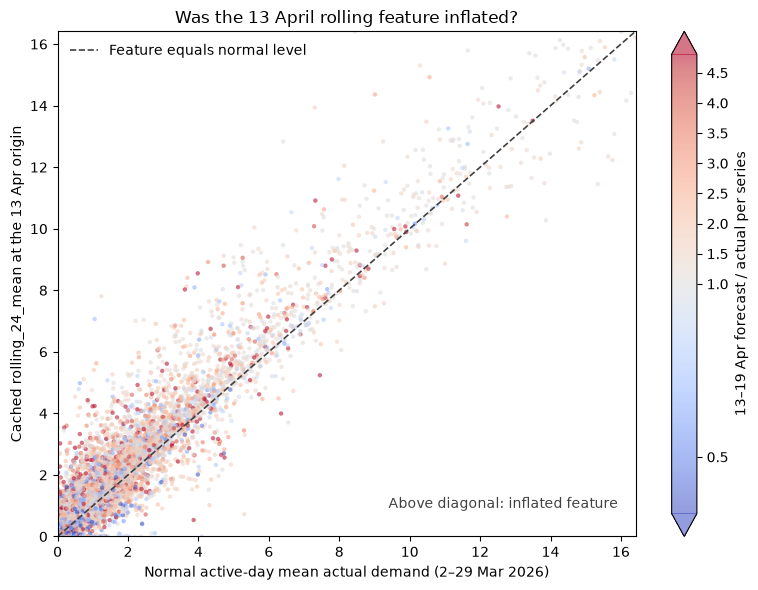

,matched_positive_actual_series,normal_baseline_mean,april_13_rolling_24_mean,share_above_diagonal,pooled_forecast_actual_ratio
0,"12,652",1.508,1.711,62.5%,1.274


In [13]:
APRIL_13_ORIGIN = pd.Timestamp('2026-04-13')
april_13_feature_path = (
    feature_generation
    / f'origin={APRIL_13_ORIGIN.date().isoformat()}'
    / 'features.parquet'
)
if not april_13_feature_path.exists():
    raise FileNotFoundError(
        f'Missing April 13 feature partition: {april_13_feature_path}'
    )

april_13_rolling_24_comparison = con.execute(
    '''
    WITH april_13_features AS (
        SELECT
            ARTIKEL_ID, MARKT_ID,
            ANY_VALUE(rolling_24_mean) AS rolling_24_mean
        FROM read_parquet(?)
        WHERE sourcing_group = ? AND category_id = ?
        GROUP BY ARTIKEL_ID, MARKT_ID
    ), normal_baseline AS (
        SELECT
            ARTIKEL_ID, MARKT_ID,
            AVG(actual) FILTER (WHERE is_active) AS normal_baseline_mean
        FROM pseudo_890_rows
        WHERE period >= DATE '2026-03-02'
            AND period < DATE '2026-03-30'
        GROUP BY ARTIKEL_ID, MARKT_ID
    ), april_13_outcome AS (
        SELECT
            ARTIKEL_ID, MARKT_ID,
            SUM(forecast) AS forecast_kg,
            SUM(actual) AS actual_kg,
            SUM(forecast) / NULLIF(SUM(actual), 0) AS forecast_actual_ratio
        FROM pseudo_890_active
        WHERE origin = DATE '2026-04-13'
        GROUP BY ARTIKEL_ID, MARKT_ID
    )
    SELECT
        f.ARTIKEL_ID, f.MARKT_ID, b.normal_baseline_mean,
        f.rolling_24_mean, o.forecast_kg, o.actual_kg,
        o.forecast_actual_ratio
    FROM april_13_features AS f
    INNER JOIN normal_baseline AS b USING (ARTIKEL_ID, MARKT_ID)
    INNER JOIN april_13_outcome AS o USING (ARTIKEL_ID, MARKT_ID)
    WHERE b.normal_baseline_mean IS NOT NULL
        AND f.rolling_24_mean IS NOT NULL
        AND o.forecast_actual_ratio IS NOT NULL
    ''',
    [str(april_13_feature_path), SOURCE_GROUP, CATEGORY_ID],
).fetchdf()

comparison_summary = pd.DataFrame({
    'matched_positive_actual_series': [len(april_13_rolling_24_comparison)],
    'normal_baseline_mean': [
        april_13_rolling_24_comparison.normal_baseline_mean.mean()
    ],
    'april_13_rolling_24_mean': [
        april_13_rolling_24_comparison.rolling_24_mean.mean()
    ],
    'share_above_diagonal': [
        april_13_rolling_24_comparison.rolling_24_mean.gt(
            april_13_rolling_24_comparison.normal_baseline_mean
        ).mean()
    ],
    'pooled_forecast_actual_ratio': [
        april_13_rolling_24_comparison.forecast_kg.sum()
        / april_13_rolling_24_comparison.actual_kg.sum()
    ],
})
plot_limit = float(april_13_rolling_24_comparison[[
    'normal_baseline_mean', 'rolling_24_mean',
]].quantile(0.99).max())
plot_rows = april_13_rolling_24_comparison.loc[
    april_13_rolling_24_comparison.normal_baseline_mean.le(plot_limit)
    & april_13_rolling_24_comparison.rolling_24_mean.le(plot_limit)
]
ratio_low, ratio_high = plot_rows.forecast_actual_ratio.quantile([0.05, 0.95])
ratio_norm = TwoSlopeNorm(
    vmin=min(float(ratio_low), 0.99),
    vcenter=1.0,
    vmax=max(float(ratio_high), 1.01),
)

fig, ax = plt.subplots(figsize=(8, 6))
points = ax.scatter(
    plot_rows.normal_baseline_mean, plot_rows.rolling_24_mean,
    c=plot_rows.forecast_actual_ratio, cmap='coolwarm', norm=ratio_norm,
    s=10, alpha=0.55, edgecolors='none', rasterized=True,
)
ax.plot(
    [0, plot_limit], [0, plot_limit], '--',
    color='0.25', linewidth=1.2, label='Feature equals normal level',
)
ax.set(
    xlim=(0, plot_limit), ylim=(0, plot_limit),
    xlabel='Normal active-day mean actual demand (2–29 Mar 2026)',
    ylabel='Cached rolling_24_mean at the 13 Apr origin',
    title='Was the 13 April rolling feature inflated?',
)
ax.text(
    0.97, 0.05, 'Above diagonal: inflated feature',
    transform=ax.transAxes, ha='right', va='bottom', color='0.25',
)
ax.legend(frameon=False, loc='upper left')
colour_bar = fig.colorbar(points, ax=ax, extend='both')
colour_bar.set_label('13–19 Apr forecast / actual per series')
fig.tight_layout()
plt.show()
display(comparison_summary.style.format({
    'matched_positive_actual_series': '{:,.0f}',
    'normal_baseline_mean': '{:.3f}',
    'april_13_rolling_24_mean': '{:.3f}',
    'share_above_diagonal': '{:.1%}',
    'pooled_forecast_actual_ratio': '{:.3f}',
}))

In [14]:
worst_days = (
    bad_days.sort_values(
        ['origin', 'article_day_absolute_error_kg'], ascending=[True, False]
    )
    .drop_duplicates('origin')
    [[
        'origin', 'period', 'weekday', 'calendar_context', 'event_name',
        'holiday_event_window', 'error_share_within_origin',
    ]]
    .rename(columns={'period': 'largest_error_period'})
)
worst_day_lifts = bad_lift_days.rename(
    columns={'period': 'largest_error_period'}
)[[
    'origin', 'largest_error_period', 'event_lift_series_coverage',
    'event_lift_series_mean', 'event_lift_series_median',
    'event_lift_pooled_occurrence', 'event_lift_pooled_quantity',
    'event_lift_pooled_total',
]]
interpretation_rows = (
    bad_origins.merge(
        bad_stage[[
            'origin', 'occurrence_gap_pp', 'positive_mean_ratio',
        ]],
        on='origin', validate='one_to_one',
    )
    .merge(
        concentration_summary[['origin', 'top_10_error_share']],
        on='origin', validate='one_to_one',
    )
    .merge(worst_days, on='origin', validate='one_to_one')
    .merge(
        worst_day_lifts, on=['origin', 'largest_error_period'],
        validate='one_to_one',
    )
    .sort_values('absolute_error_rank')
)

def lift_summary(row):
    if pd.isna(row.event_lift_series_median):
        series_text = 'series lift missing'
    else:
        series_text = (
            f'series lift mean/median {row.event_lift_series_mean:.3f}/'
            f'{row.event_lift_series_median:.3f} '
            f'({row.event_lift_series_coverage:.1%} coverage)'
        )
    if pd.isna(row.event_lift_pooled_occurrence):
        pooled_text = 'pooled lifts missing'
    else:
        pooled_text = (
            'pooled occurrence/quantity/total lifts '
            f'{row.event_lift_pooled_occurrence:.3f}/'
            f'{row.event_lift_pooled_quantity:.3f}/'
            f'{row.event_lift_pooled_total:.3f}'
        )
    return f'{series_text}; {pooled_text}'

week_lines = []
for row in interpretation_rows.itertuples():
    context = row.calendar_context
    if row.event_name != 'none':
        context += f', {row.event_name}, {row.holiday_event_window}'
    week_lines.append(
        f'- **{row.origin:%Y-%m-%d}:** {row.diagnosis} (weekly ratio '
        f'**{row.ratio:.3f}**). The largest-error day is '
        f'**{row.largest_error_period:%Y-%m-%d}** ({row.weekday}; {context}) '
        f'with **{row.error_share_within_origin:.1%}** of weekly error. '
        f'Occurrence error is **{row.occurrence_gap_pp:+.2f} points** and the '
        f'positive-quantity ratio is **{row.positive_mean_ratio:.3f}**. On that '
        f'day: {lift_summary(row)}. The top ten articles contribute '
        f'**{row.top_10_error_share:.1%}** of weekly error.'
    )

day_before_validation = validation_occurrence.loc[
    validation_occurrence.calendar_context.eq('day before public holiday'),
    'occurrence_gap_pp',
]
validation_text = (
    ' Rolling validation underpredicts occurrence on days before public '
    f'holidays by **{-day_before_validation.iloc[0]:.2f} percentage points**.'
    if not day_before_validation.empty else ''
)
display(Markdown(
    '## Interpretation\n\n'
    'The three largest article-day absolute-error weeks are genuine bad weeks, '
    'not small-denominator WAPE artifacts. Their diagnostics and the lift inputs '
    'on each week’s largest-error day are:\n\n'
    + '\n'.join(week_lines)
    + '\n\nThe pooled lifts describe a market-wide event effect and therefore cannot '
      'explain article-store differences within a day. The series lift varies '
      'across rows, but it is still only one of several correlated event and '
      'annual-history features.'
    + validation_text
))

## Interpretation

The three largest article-day absolute-error weeks are genuine bad weeks, not small-denominator WAPE artifacts. Their diagnostics and the lift inputs on each week’s largest-error day are:

- **2026-05-18:** level: underforecast (weekly ratio **0.757**). The largest-error day is **2026-05-23** (Saturday; ordinary, Pfingstmontag, before_holiday_1_3d) with **41.3%** of weekly error. Occurrence error is **-0.69 points** and the positive-quantity ratio is **0.759**. On that day: series lift mean/median 2.526/1.035 (81.6% coverage); pooled occurrence/quantity/total lifts 1.095/1.203/1.317. The top ten articles contribute **57.2%** of weekly error.
- **2026-04-27:** level: underforecast (weekly ratio **0.777**). The largest-error day is **2026-04-30** (Thursday; day before public holiday, Erster Mai, before_holiday_1_3d) with **52.9%** of weekly error. Occurrence error is **-2.62 points** and the positive-quantity ratio is **0.804**. On that day: series lift mean/median 3.764/0.543 (82.7% coverage); pooled occurrence/quantity/total lifts 1.170/1.437/1.681. The top ten articles contribute **58.5%** of weekly error.
- **2026-03-30:** level: underforecast (weekly ratio **0.806**). The largest-error day is **2026-04-04** (Saturday; school holiday, Karfreitag, after_holiday_1_3d) with **35.1%** of weekly error. Occurrence error is **-2.36 points** and the positive-quantity ratio is **0.829**. On that day: series lift mean/median 2.884/0.645 (83.4% coverage); pooled occurrence/quantity/total lifts 1.238/1.492/1.847. The top ten articles contribute **54.1%** of weekly error.

The pooled lifts describe a market-wide event effect and therefore cannot explain article-store differences within a day. The series lift varies across rows, but it is still only one of several correlated event and annual-history features. Rolling validation underpredicts occurrence on days before public holidays by **4.24 percentage points**.

## Scope and limitations

The analysis is diagnostic and observational. Calendar coincidence does not establish causality, and the top-three selection is descriptive rather than a statistical anomaly test. Initial fit rows can confirm recurring demand structure but cannot measure fitted-model error because in-sample predictions were not persisted. Rolling validation predictions cover the occurrence stage only; positive-quantity generalization is therefore assessed from actual historical quantities rather than validation forecasts.